In [ ]:
!pip install pandas matplotlib seaborn wordcloud scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# Pengaturan visualisasi standar agar rapi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

In [ ]:
# Membaca dataset
df = pd.read_csv('dataset/bbc-news-data.csv', sep='\t')

# Menampilkan 5 data teratas
display(df.head())

# Menampilkan informasi dataset
print("\n--- Info Dataset ---")
display(df.info())

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...



--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  2225 non-null   str  
 1   filename  2225 non-null   str  
 2   title     2225 non-null   str  
 3   content   2225 non-null   str  
dtypes: str(4)
memory usage: 69.7 KB


None

In [3]:
print("--- Pengecekan Missing Values ---")
display(df.isnull().sum())

print("\n--- Pengecekan Duplikat ---")
print(f"Total baris duplikat persis: {df.duplicated().sum()}")

--- Pengecekan Missing Values ---


category    0
filename    0
title       0
content     0
dtype: int64


--- Pengecekan Duplikat ---
Total baris duplikat persis: 0


In [4]:
# Menghitung jumlah kata pada judul dan isi berita
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))
df['content_word_count'] = df['content'].apply(lambda x: len(str(x).split()))

# Menampilkan statistik deskriptif dari panjang teks
display(df[['title_word_count', 'content_word_count']].describe())

,title_word_count,content_word_count
count,2225.000000,2225.000000
mean,5.204494,378.835955
std,0.865494,238.220755
min,3.000000,84.000000
25%,5.000000,240.000000
50%,5.000000,326.000000
75%,6.000000,466.000000
max,9.000000,4428.000000


C:\Users\axels\AppData\Local\Temp\ipykernel_9092\3664793004.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='category', order=df['category'].value_counts().index, palette='viridis')


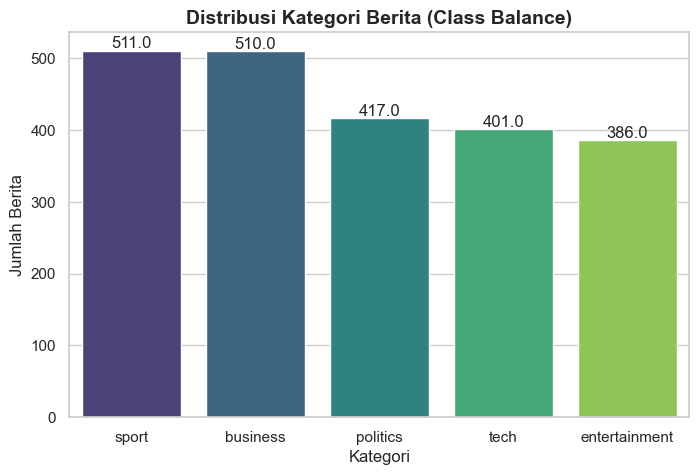

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='category', order=df['category'].value_counts().index, palette='viridis')
plt.title('Distribusi Kategori Berita (Class Balance)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah Berita', fontsize=12)

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

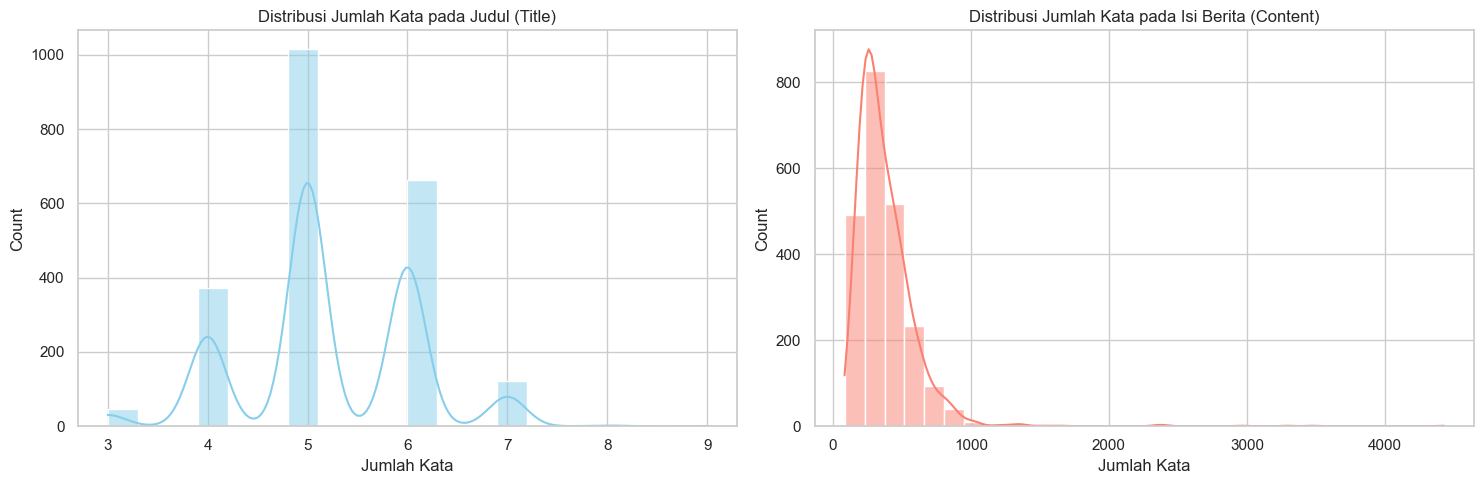

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram panjang judul
sns.histplot(df['title_word_count'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Jumlah Kata pada Judul (Title)')
axes[0].set_xlabel('Jumlah Kata')

# Histogram panjang konten
sns.histplot(df['content_word_count'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Jumlah Kata pada Isi Berita (Content)')
axes[1].set_xlabel('Jumlah Kata')

plt.tight_layout()
plt.show()

C:\Users\axels\AppData\Local\Temp\ipykernel_9092\64365918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='content_word_count', palette='Set2')


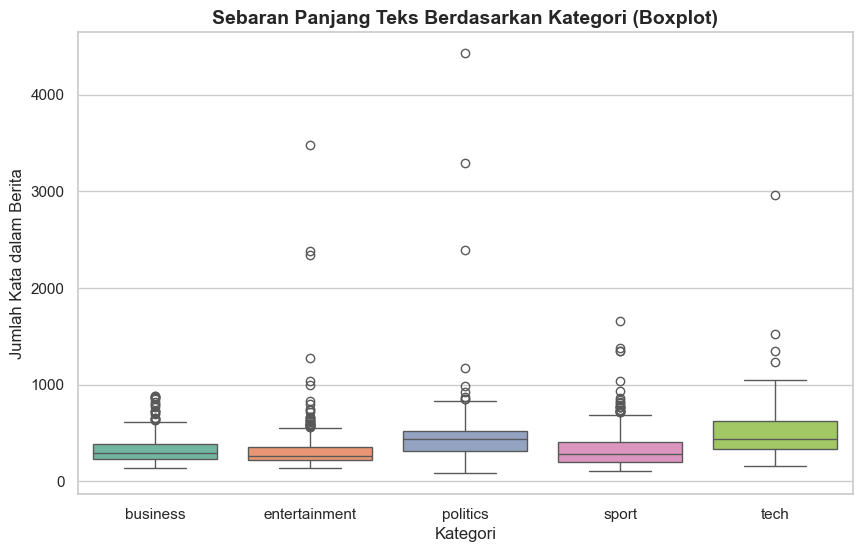

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='content_word_count', palette='Set2')
plt.title('Sebaran Panjang Teks Berdasarkan Kategori (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah Kata dalam Berita', fontsize=12)
plt.show()

C:\Users\axels\AppData\Local\Temp\ipykernel_9092\1427370683.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='title_word_count', palette='Set2')


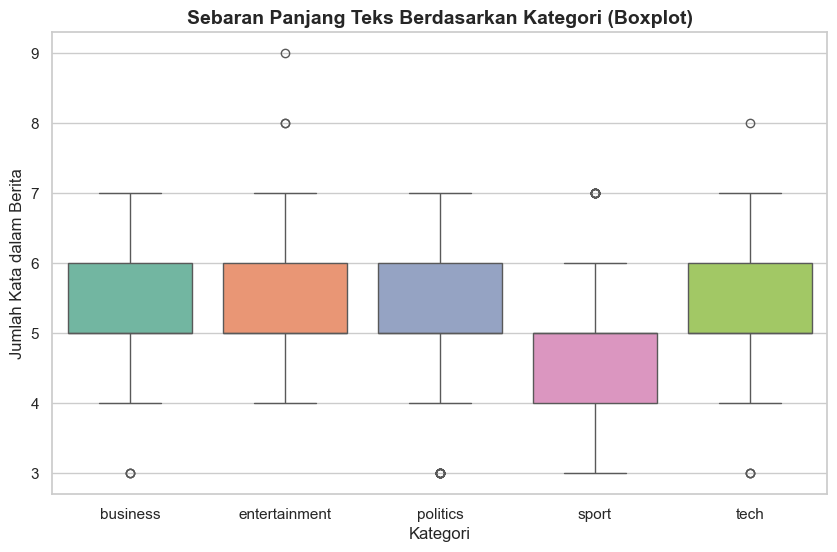

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='title_word_count', palette='Set2')
plt.title('Sebaran Panjang Teks Berdasarkan Kategori (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah Kata dalam Berita', fontsize=12)
plt.show()

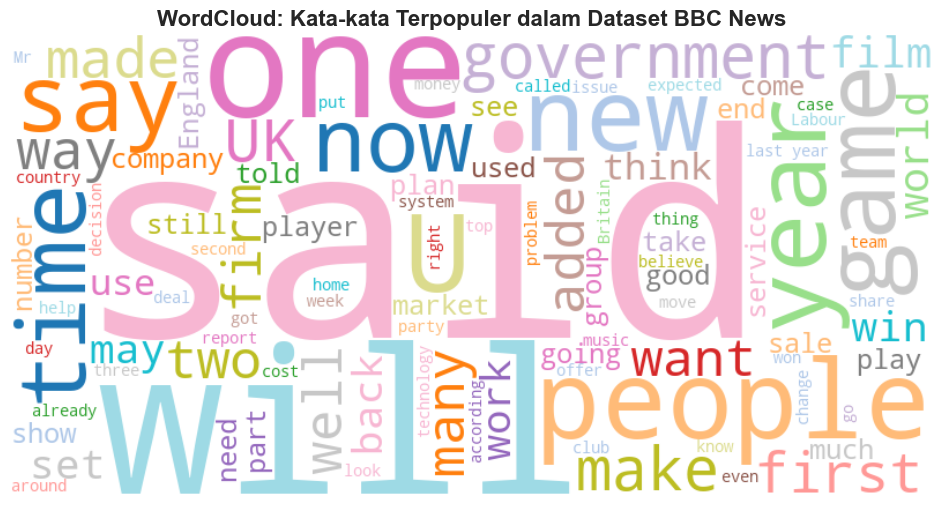

In [8]:
# Menggabungkan semua teks konten menjadi satu string raksasa
text_corpus = " ".join(df['content'].values)

# Membuat WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab20', max_words=100).generate(text_corpus)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: Kata-kata Terpopuler dalam Dataset BBC News', fontsize=16, fontweight='bold')
plt.show()

C:\Users\axels\AppData\Local\Temp\ipykernel_9092\2012977258.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bigram_df, x='Frekuensi', y='Frasa (Bigram)', palette='magma')


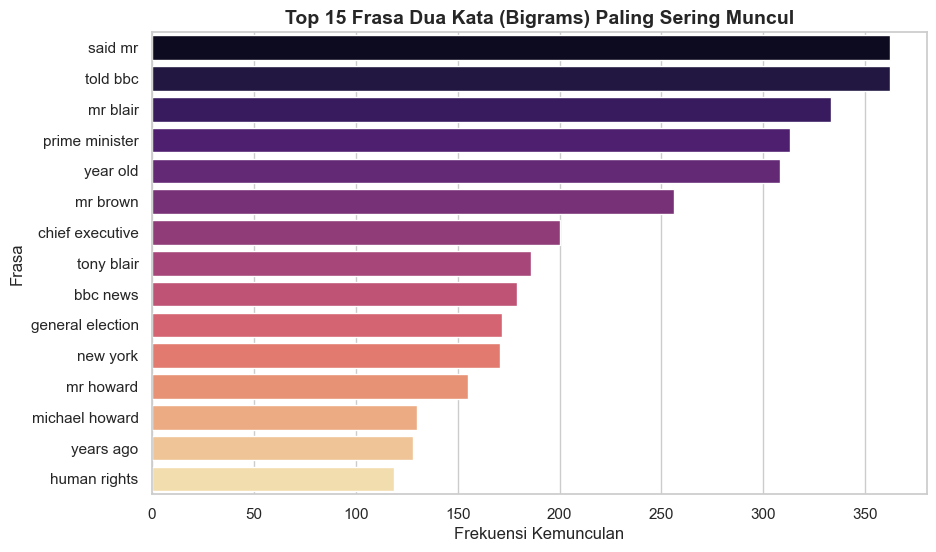

In [10]:
def get_top_ngram(corpus, n=None, ngram=2):
    # Menggunakan stop_words='english' untuk membuang kata umum (the, is, and)
    vec = CountVectorizer(ngram_range=(ngram, ngram), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Mengambil top 15 Bigrams (frasa 2 kata)
top_bigrams = get_top_ngram(df['content'], n=15, ngram=2)
bigram_df = pd.DataFrame(top_bigrams, columns=['Frasa (Bigram)', 'Frekuensi'])

plt.figure(figsize=(10, 6))
sns.barplot(data=bigram_df, x='Frekuensi', y='Frasa (Bigram)', palette='magma')
plt.title('Top 15 Frasa Dua Kata (Bigrams) Paling Sering Muncul', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi Kemunculan')
plt.ylabel('Frasa')
plt.show()


--- Fokus pada Fitur Utama: Judul (Title) ---


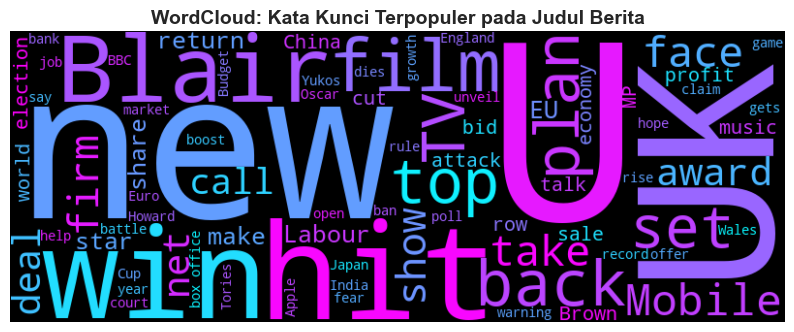

Top 10 Kata Terbanyak di Judul:
- new: 69 kali
- uk: 61 kali
- blair: 49 kali
- film: 46 kali
- tv: 41 kali
- hits: 32 kali
- set: 32 kali
- eu: 31 kali
- net: 31 kali
- deal: 30 kali


In [11]:
# --- EDA KHUSUS UNTUK FITUR MODEL (TITLE) ---
print("\n--- Fokus pada Fitur Utama: Judul (Title) ---")

# WordCloud khusus untuk judul
title_corpus = " ".join(df['title'].values)
wordcloud_title = WordCloud(width=800, height=300, background_color='black', 
                            colormap='cool', max_words=80).generate(title_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_title, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: Kata Kunci Terpopuler pada Judul Berita', fontsize=14, fontweight='bold')
plt.show()

# Melihat top kata pada judul
vec_title = CountVectorizer(stop_words='english').fit(df['title'])
bag_of_words_title = vec_title.transform(df['title'])
sum_words_title = bag_of_words_title.sum(axis=0) 
words_freq_title = [(word, sum_words_title[0, idx]) for word, idx in vec_title.vocabulary_.items()]
words_freq_title = sorted(words_freq_title, key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Kata Terbanyak di Judul:")
for word, freq in words_freq_title:
    print(f"- {word}: {freq} kali")